In [1]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


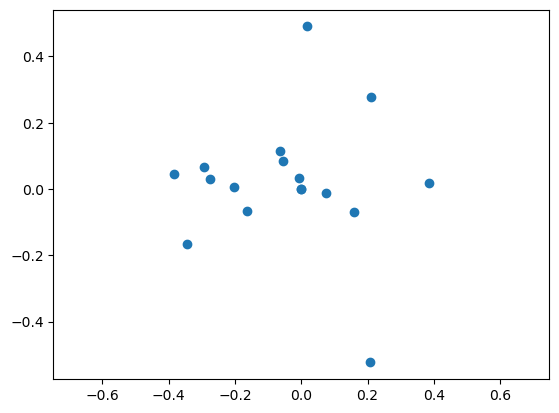

In [85]:
def init_trajectory(control_point_num):  # 生成初始轨迹
    xs, ys, rotations = resample_polyline([
        [0, 0, 0],
        [0, 0, 2 * np.pi]
    ], control_point_num).T
    return xs, ys, rotations

xs, ys, rotations = init_trajectory(  # 初始轨迹
    control_point_num=17,  # 轨迹的控制点数量
)

xs[1:-1] += np.random.randn(len(xs) - 2) * 0.2
ys[1:-1] += np.random.randn(len(ys) - 2) * 0.2

plt.scatter(xs, ys)
plt.axis('equal')
pass

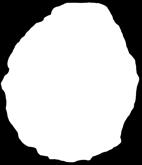

In [37]:
wall_image = Image.open('../input_images/鸡块高清蒙版.png')

wall_numpy = np.array(wall_image).T > 0  # 读取图片并转换为布尔数组
assert len(wall_numpy.shape) == 2, "Image must be grayscale"

wall_taichi = ti.field(dtype=ti.i8, shape=wall_numpy.shape)
wall_taichi.from_numpy(wall_numpy.astype(np.int8))

wall_image_down_sampled = wall_image.convert('1').convert('RGB').resize((wall_image.width // 8, wall_image.height // 8))
wall_image_down_sampled

In [6]:
wall_taichi.shape

(1140, 1320)

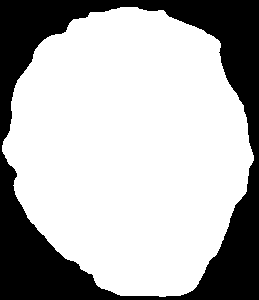

In [ ]:
# 可视化墙（白色区域为墙）

from utils import test_forbidden_function

@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    return wall_taichi[
        max(0, min(wall_taichi.shape[0] - 1, int((x2 + 0.5) * wall_taichi.shape[1] - (wall_taichi.shape[1] - wall_taichi.shape[0]) / 2))),
        max(0, min(wall_taichi.shape[1] - 1, int((y2 + 0.5) * wall_taichi.shape[1])))
    ]

image = test_forbidden_function(
    is_forbidden,
    -wall_taichi.shape[0] / wall_taichi.shape[1] / 2, wall_taichi.shape[0] / wall_taichi.shape[1] / 2, -0.5, 0.5, [int(300 * wall_taichi.shape[0] / wall_taichi.shape[1]), 300],
    # wall_normal=[0, 0.05]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [ ]:
xs, ys, rotations = np.load('../trajectory/能让鸡块旋转一周的房间_2/sofa_780.npy')

(-0.11497911243417552,
 0.170461193823516,
 -0.135254755540265,
 0.12002072643354042)

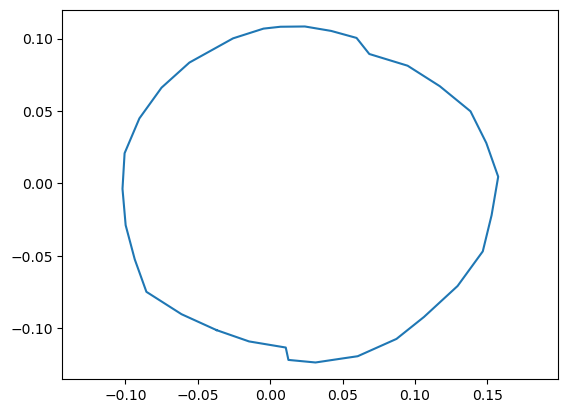

In [93]:
plt.plot(xs, ys)
plt.axis('equal')

Initial survivors: 3.2278823852539062
iter 500 / 10000, maximal_area=3.2282142639160156
iter 1000 / 10000, maximal_area=3.228321075439453
iter 1500 / 10000, maximal_area=3.2283668518066406
iter 2000 / 10000, maximal_area=3.2283897399902344
iter 2500 / 10000, maximal_area=3.2284011840820312
iter 3000 / 10000, maximal_area=3.228412628173828
iter 3500 / 10000, maximal_area=3.228435516357422
iter 4000 / 10000, maximal_area=3.2284622192382812
iter 4500 / 10000, maximal_area=3.2284622192382812
iter 5000 / 10000, maximal_area=3.2284698486328125
iter 5500 / 10000, maximal_area=3.228485107421875
iter 6000 / 10000, maximal_area=3.2285003662109375
iter 6500 / 10000, maximal_area=3.2285003662109375
iter 7000 / 10000, maximal_area=3.2285003662109375
iter 7500 / 10000, maximal_area=3.2285003662109375
iter 8000 / 10000, maximal_area=3.2285079956054688
iter 8500 / 10000, maximal_area=3.2285079956054688
iter 9000 / 10000, maximal_area=3.2285118103027344
iter 9500 / 10000, maximal_area=3.228519439697265

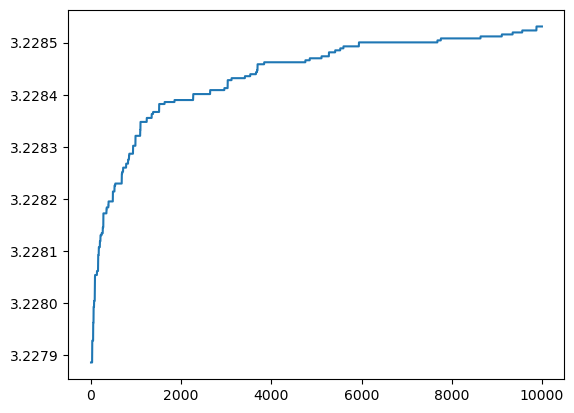

In [91]:
sofa_w, sofa_h = 2, 2   # 求解域的尺寸

best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    # xs,  # 上采样使得轨迹分辨率翻倍时注释掉这三行
    # ys,
    # rotations,
    initial_xs=zoom(xs, zoom=2, order=1),  # 保持轨迹分辨率时注释掉这三行
    initial_ys=zoom(ys, zoom=2, order=1),
    initial_rotations=zoom(rotations, zoom=2, order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    mutation_sigma_pos = 0.002,  # 变异率 0.002
    mutation_sigma_rotation = 0,  # 变异率
    iterations = 10000,  # 10000
    trajectory_upsampling=41,  # 41 101
    resolution=1024,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=100,
    save_image_path='../images/能让鸡块旋转一周的房间_4/sofa_',
    save_image_start_id=200,  # 文件起始标号
    save_trajectory_path='../trajectory/能让鸡块旋转一周的房间_4/sofa_',
    boundary_conditions='periodic'  # 循环边界条件
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)

In [92]:
area = sofa_w * sofa_h - best_score  # 房间面积
area

0.7714691162109375

目前最优：0.7708823704719545 / 0.7718362185118407 = 0.9987641833629869

# 求包含原图形的最小圆盘

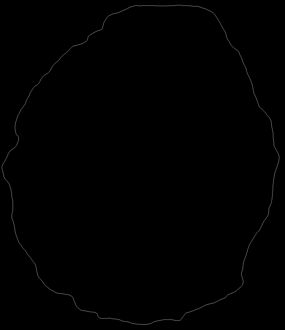

In [58]:
wall_boundary_numpy = np.logical_and(
    wall_numpy,
    np.logical_not((
        np.roll(wall_numpy, 1, axis=0),
        np.roll(wall_numpy, -1, axis=0),
        np.roll(wall_numpy, 1, axis=1),
        np.roll(wall_numpy, -1, axis=1),
    )).any(axis=0)
)  # 所有周围有黑像素的白像素
wall_boundary_image = Image.fromarray(np.array(wall_boundary_numpy.T * 255, dtype=np.uint8))
wall_image_down_sampled = wall_boundary_image.convert('1').convert('RGB').resize((wall_boundary_image.width // 4, wall_boundary_image.height // 4))  # 降采样以可视化在笔记本中
wall_image_down_sampled

In [59]:
coordinates = np.column_stack(np.where(wall_boundary_numpy))  # 白色像素的位置
coordinates.shape

(3496, 2)

654.2768767623654

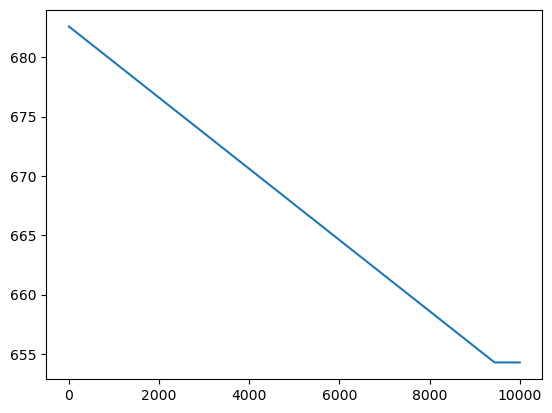

In [74]:
# 梯度下降法求包含所有像素点的最小圆的中心

import matplotlib.pyplot as plt

def compute_loss_and_grad(center):
    squared_distances = np.sum((coordinates - center) ** 2, axis=1)
    i = np.argmax(squared_distances)
    v = center - coordinates[i]
    v /= np.linalg.norm(v)
    return squared_distances[i] ** 0.5, v

def gradient_descent(initial_center, learning_rate=0.003, iterations=10000):
    center = initial_center
    losses = []
    for _ in range(iterations):
        loss, grad = compute_loss_and_grad(center)
        center -= learning_rate * grad
        losses.append(loss)
    return center, losses

initial_center = np.mean(coordinates, axis=0)
optimal_center, losses = gradient_descent(initial_center)
radius = losses[-1]
plt.plot(losses)
radius

In [75]:
area_disk = np.pi * radius ** 2 / wall_taichi.shape[1] ** 2
f'{area} / {area_disk} = {area / area_disk}'

'0.7708823704719545 / 0.7718362185118407 = 0.9987641833629869'